In [1]:
import numpy as np
import pandas as pd
import pickle as pkl

In [2]:
pd.__version__

'2.3.3'

In [3]:
import pandas as pd
print(pd.__version__)


2.3.3


In [4]:
chunk_metadata=pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\phase_2_chunk_metadata.pkl")

In [5]:
user_embeddings= pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\phase_2_user_emb.pkl")

In [6]:
item_emb_df=pd.DataFrame(pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\phase_2_item_emb.pkl"))

In [7]:
item_emb_df ## item_emb corresponding to chunk_metadata

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.005983,-0.114306,0.010787,0.013902,0.033052,-0.035159,0.001696,-0.002761,-0.159066,6.712158e-02,...,0.122445,0.056867,0.015835,-0.095521,-0.017067,0.039663,0.001824,0.018260,0.024497,0.049461
1,0.018841,-0.049462,-0.019324,0.047654,-0.030958,-0.132104,-0.010963,-0.022627,-0.104423,7.471888e-02,...,0.076173,0.059800,-0.013842,-0.015980,-0.063965,0.043082,0.016098,-0.015716,0.018855,0.017013
2,-0.034618,-0.012705,-0.009682,0.047390,-0.045320,-0.134024,-0.003128,0.022114,-0.095068,7.450934e-02,...,0.087518,0.066692,-0.054004,0.044697,-0.064051,0.010807,0.019182,0.034702,0.044463,0.004105
3,0.009912,-0.084497,0.009273,-0.009979,0.007115,-0.015803,0.008705,-0.030429,-0.014096,2.075856e-02,...,0.082581,-0.003411,0.063104,-0.090111,0.013327,0.111447,0.068637,-0.040063,0.059502,0.052815
4,-0.057536,-0.070677,0.072725,-0.012639,-0.055164,-0.054520,-0.038707,0.023866,-0.129048,-5.992439e-02,...,0.055993,0.021843,0.013714,-0.114427,-0.029592,0.059157,-0.040263,0.052765,0.028108,0.044863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14556,-0.102176,0.003083,-0.050815,-0.009713,-0.004004,-0.042375,-0.042589,-0.008008,0.058870,9.889977e-03,...,0.067131,0.128255,0.014666,-0.000209,-0.010557,0.000473,-0.008513,0.004577,-0.061755,-0.077331
14557,-0.041736,-0.045683,0.018611,-0.063583,-0.093122,0.015551,-0.013019,-0.012797,-0.100758,-7.014660e-02,...,-0.031689,-0.067450,0.006950,0.004497,0.102326,-0.006385,0.080737,0.011633,-0.035397,0.010775
14558,-0.039387,0.060689,-0.010403,-0.019768,0.012824,0.003527,0.066864,-0.023271,0.008612,-4.557156e-02,...,-0.006619,0.031710,-0.038147,0.015515,-0.042890,-0.034630,0.044189,-0.078445,-0.074800,0.028106
14559,-0.138386,0.002937,-0.086947,0.040883,0.021222,0.076411,0.052605,0.005755,0.036329,-8.086116e-08,...,0.028251,0.093383,0.053800,0.001946,-0.087360,0.037808,0.030206,0.010560,-0.004265,0.001004


In [8]:
df1=pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\phase_2_item.pkl")

In [9]:
from sentence_transformers import SentenceTransformer
import torch
target_domains = [
    "Movie",
    "TV Series",
    "Documentary",
    "Courses"
]
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')
target_emb = model_sbert.encode(target_domains, convert_to_tensor=True)
def map_domain_sbert(domain):
    
    if domain is None or str(domain) == "<NA>":
        return "Other"

    domain = str(domain).lower()

    emb = model_sbert.encode(domain, convert_to_tensor=True)

    scores = torch.matmul(emb, target_emb.T)

    best_idx = torch.argmax(scores).item()

    return target_domains[best_idx]
df1['normalized_domain'] = df1['combined'].apply(map_domain_sbert)

c:\Users\nihal\torch_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7003.31it/s]


In [10]:
df1.drop(columns=['combined'],inplace=True)

In [11]:
df1.head(5)

,title,domain,metadata,movie_id,normalized_domain
0,machine learning specialization,Machine Learning,"Decision Trees, Artificial Neural Network, Log...",n0,Courses
1,introduction to data science specialization,Data Analysis,"Data Science, Relational Database Management S...",n1,Courses
2,data science fundamentals with python and sql ...,Data Analysis,"Data Science, Github, Python Programming, Jupy...",n2,Courses
3,key technologies for business specialization,Business Essentials,"Data Science, Artificial Intelligence (AI), Bu...",n3,Courses
4,deep learning specialization,Machine Learning,"Artificial Neural Network, Convolutional Neura...",n4,Courses


In [12]:

import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
class RecommenderModel(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        input_dim = emb_dim * 3  # user + item + interaction

        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.LayerNorm(256),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 1)
        )

    def forward(self, user, item):
        interaction = user * item  # element-wise
        x = torch.cat([user, item, interaction], dim=1)
        return self.model(x)

In [ ]:
import torch.nn.functional as F
# bpr loss---> In PyTorch, BPR loss is implemented by sampling a positive item and a negative item for each user and calculating 
#the loss as -log(σ(y^ui - y^uj)).This loss function is used to train the model to rank positive items higher than negative items.
# The model updates its parameters based on the sampled items and the calculated loss, leading to improved recommendation quality.

def bpr_loss(pos_scores, neg_scores):
    return -torch.mean(F.logsigmoid(pos_scores - neg_scores))

In [16]:
model = RecommenderModel(emb_dim=384).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [17]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print(next(model.parameters()).device)

CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
cuda:0


In [18]:
movie_to_domain = dict(zip(df1['movie_id'], df1['normalized_domain']))
index_to_domain = {
    idx: movie_to_domain.get(chunk_metadata[idx]['id'], "Other")
    for idx in range(len(chunk_metadata))
}


In [19]:
def balance_training_data(df):
    
    domain_counts = df['normalized_domain'].value_counts()
    min_count = domain_counts.min()

    balanced = []

    for domain in domain_counts.index:
        subset = df[df['normalized_domain'] == domain].sample(min_count)
        balanced.append(subset)

    return pd.concat(balanced).reset_index(drop=True)

In [20]:
from collections import defaultdict

domain_to_indices = defaultdict(list)

for idx in range(len(item_emb_df)):

    movie_id = chunk_metadata[idx]['id']

    domain = movie_to_domain.get(movie_id, "Other")

    domain_to_indices[domain].append(idx)

In [ ]:

train_acc_list = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

item_tensor = torch.tensor(item_emb_df.values, dtype=torch.float32).to(device)

for i in range(1, 5001):

    df = pd.DataFrame(pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\user\phase_2_user_part_{}.pkl".format(i)))
    df = df[[0, 3, 8]]  # 0-->user_id 3--->movie_id 8--->embeddings
    df.rename(columns={0: 'user_id', 3: 'movie_id', 8: 'embedding'}, inplace=True)
    
    pair_rows = []

    for _, row in df.iterrows():

        user_id = row['user_id']
        pos_movie_id = row['movie_id']
        pos_item_emb = row['embedding']

        if user_id not in user_embeddings:
            continue

        user_emb = user_embeddings[user_id]

        user_domain = movie_to_domain.get(pos_movie_id, "Other")
        indices = domain_to_indices[user_domain]

        # random negative samples
        random_negs = []
        trials = 0

        while len(random_negs) < 45 and trials < 2000:
            trials += 1
            idx = np.random.choice(indices)

            item_id = chunk_metadata[idx]['id']
            if item_id == pos_movie_id:
                continue

            random_negs.append(item_emb_df.iloc[idx].values)

        # hard neg samples
        user_vec = torch.tensor(user_emb.reshape(1, -1), dtype=torch.float32).to(device)

        scores = torch.matmul(user_vec, item_tensor.T)[0]
        top_indices = torch.topk(scores, k=2000).indices.tolist()

        hard_negs = []

        for idx in top_indices:
            item_id = chunk_metadata[idx]['id']

            if item_id == pos_movie_id:
                continue

            hard_negs.append(item_emb_df.iloc[idx].values)

            if len(hard_negs) >= 45:
                break

        #create pairs (pos emb ,neg emb)
        for neg_emb in random_negs + hard_negs:
            pair_rows.append({
                "user": user_emb,
                "pos": pos_item_emb,
                "neg": neg_emb
            })

    # data
    pair_df = pd.DataFrame(pair_rows)

    user_mat = np.vstack(pair_df['user'].values)
    pos_mat  = np.vstack(pair_df['pos'].values)
    neg_mat  = np.vstack(pair_df['neg'].values)

    user_t = torch.tensor(user_mat, dtype=torch.float32).to(device)
    pos_t  = torch.tensor(pos_mat, dtype=torch.float32).to(device)
    neg_t  = torch.tensor(neg_mat, dtype=torch.float32).to(device)

    # train 
    model.train()
    batch_size = 256

    correct_total = 0
    total = 0

    for start in range(0, user_t.shape[0], batch_size):

        batch_user = user_t[start:start+batch_size]
        batch_pos  = pos_t[start:start+batch_size]
        batch_neg  = neg_t[start:start+batch_size]

        if batch_user.shape[0] < 2:
            continue

        optimizer.zero_grad()

        pos_scores = model(batch_user, batch_pos)
        neg_scores = model(batch_user, batch_neg)

        loss = bpr_loss(pos_scores, neg_scores)

        loss.backward()
        optimizer.step()

        correct = (pos_scores > neg_scores).float().sum().item()
        correct_total += correct
        total += batch_user.shape[0]

    train_acc = correct_total / total if total > 0 else 0
    train_acc_list.append(train_acc)

    print(f"Chunk {i} | Pairwise Acc: {train_acc:.4f}")

    # clean all the intermediate data
    del pair_df, user_mat, pos_mat, neg_mat
    del user_t, pos_t, neg_t
    torch.cuda.empty_cache()

Chunk 1 | Pairwise Acc: 0.9800
Chunk 2 | Pairwise Acc: 0.9961
Chunk 3 | Pairwise Acc: 0.9965


KeyboardInterrupt: 

In [ ]:
import os
import torch

base_path = r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset"

torch.save(model.state_dict(), os.path.join(base_path, "phase_3_model_2.pt"))

In [ ]:
user_movie_list=[]
for i in range(1, 5001):

    df = pd.DataFrame(pd.read_pickle(r"C:\nihal\python\NLP\Reccomender_system\Cleaned_dataset\user\phase_2_user_part_{}.pkl".format(i)))
    df = df[[0, 3, 8]]  # 0-->user_id 3--->movie_id 8--->embeddings
    df.rename(columns={0: 'user_id', 3: 'movie_id', 8: 'embedding'}, inplace=True)
    
    for _, row in df.iterrows():
        user_id, movie_id, item_emb = row
        if user_id in user_embeddings:
            user_movie_list.append({
            'user_id': user_id,
            'movie_id': movie_id
                })
user_movie=pd.DataFrame(user_movie_list)
del user_movie_list

In [ ]:
user_id="user_02660"


user_vec = user_embeddings[user_id].reshape(1, -1)
user_vec_t = torch.tensor(user_vec, dtype=torch.float32).to(device)

sim_scores = torch.matmul(user_vec_t, item_tensor.T)[0]
candidate_indices = torch.topk(sim_scores, k=100).indices.cpu().numpy()

seen_items = set(
    user_movie[user_movie['user_id'] == user_id]['movie_id'].values
)

candidate_indices = [
    idx for idx in candidate_indices
    if chunk_metadata[idx]['id'] not in seen_items
]
user_vec = user_embeddings[user_id].reshape(1, -1)

item_mat = item_emb_df.iloc[candidate_indices].values

user_t = torch.tensor(user_vec, dtype=torch.float32).to(device)
item_t = torch.tensor(item_mat, dtype=torch.float32).to(device)

# repeat user for all items
user_t = user_t.repeat(item_t.shape[0], 1)

model.eval()
with torch.no_grad():
    scores = model(user_t, item_t).cpu().numpy().flatten()

top_k = 10
top_indices = np.argsort(scores)[-top_k:][::-1]

final_indices = [candidate_indices[i] for i in top_indices]

final_ids = [chunk_metadata[idx]['id'] for idx in final_indices]


id_score_map = dict(zip(final_ids, scores[top_indices]))

results = df1[df1['movie_id'].isin(final_ids)].copy()
results["score"] = results["movie_id"].map(id_score_map)

results = results.sort_values("score", ascending=False).reset_index(drop=True)

print(results.head(10))

            title       domain          metadata    movie_id  \
0  family kingdom        Movie         Adventure  movie_0840   
1      city queen  Documentary            Family  movie_0043   
2   family legend        Movie      Family Sport  movie_0451   
3    family story    TV Series               War  movie_0404   
4     family king        Movie               War  movie_0931   
5  family mystery    TV Series        War Family  movie_0822   
6   secret family        Movie  Thriller Fantasy  movie_0445   
7           a day        Movie            Family  movie_0712   
8   secret legend        Movie            Family  movie_0048   
9         big ice  Documentary  Family Adventure  movie_0369   

  normalized_domain      score  
0             Movie -14.052860  
1       Documentary -14.277094  
2             Movie -14.286934  
3         TV Series -14.558565  
4             Movie -14.631669  
5         TV Series -14.804883  
6             Movie -14.944227  
7             Movie -15.051851 

In [36]:
# 1. Create a list of filtered DataFrames
frames = [df1[df1['movie_id'] == i] for i in seen_items]

# 2. Combine them into one single DataFrame
ans = pd.concat(frames, ignore_index=True)
ans

,title,domain,metadata,movie_id,normalized_domain
0,house war,Movie,Sci-Fi,movie_0300,Movie
1,city quest,Documentary,Drama,movie_0575,Documentary
2,mission dream,Movie,Biography,movie_0057,Movie
3,our legend,Movie,War,movie_0836,Movie
4,queenmission,TV Series,Adventure,movie_0446,TV Series
5,old house,TV Series,Comedy,movie_0186,TV Series
6,secret house,TV Series,Sci-Fi,movie_0515,TV Series
7,family mission,Movie,Documentary,movie_0189,Documentary
8,new story,Movie,Horror,movie_0537,Movie
9,princess city,TV Series,Animation,movie_0871,TV Series


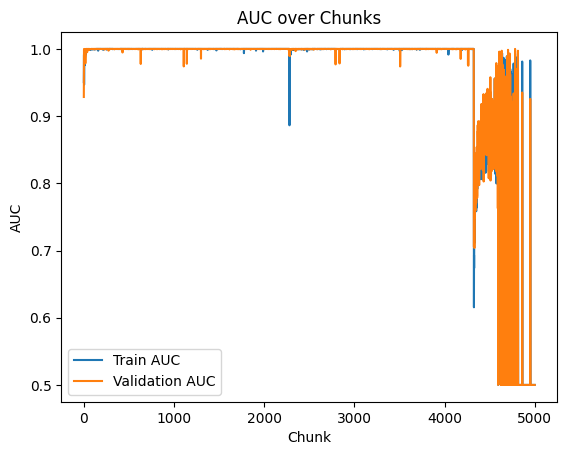

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_auc_list, label='Train AUC')
plt.plot(val_auc_list, label='Validation AUC')

plt.xlabel("Chunk")
plt.ylabel("AUC")
plt.title("AUC over Chunks")
plt.legend()

plt.show()

In [ ]:
#User Embedding
#↓
#Candidate Retrieval (SBERT similarity)
#↓
#Remove Seen Items
#↓
#BPR Neural Ranking
#↓
#Top-K Recommendations
# this flow is for phase-3 ,we need impore the retreival sytem now ,the model is perfect .